In [1]:
import xarray as xr
import os
import matplotlib.pyplot as plt
import numpy as np
from pyproj import CRS
import glob

datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/'
# datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/data_submission/RME2009_fulldata/'
# datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/RME2009/ProcessedMay25_xyz/'

The NetCDF files are not self-describing - the variable names are not clear,  the variables contain no attributes other than the name of the data field, and there are no global attributes, including no grid mapping variable to describe the coordinate system/projection of the data. Moreover, the netcdf files do not plot correctly because the x variable contains NaNs (as do the z variables). If x, y, and z variables are to be coordinate variables, they cannot have NaNs.

In [17]:
ncfiles = glob.glob(datapath+'*.nc')
ncfiles.sort()
ncfiles

['/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/bigDriftWofNorthline.nc']

In [18]:
# for file in ncfiles:
#         # open old dataset
#         ds = xr.open_dataset(file, engine="netcdf4")
        
# #         print(len(ds.coords))
#         if len(ds.coords) < 2: # remove the files without geolocation
#             print(file)
#             os.remove(file)
        
#         else:
#             print(ds)
#             # determine which coordinates to remove
#             remove_x_idxs = np.where((np.isnan(ds.x) | np.isnan(ds.y)))[0]

#             # grab the adjusted PDATA (remove parts of file with empty coordinates)
#             PDATA = xr.DataArray(np.delete(ds.PDATA,remove_x_idxs,axis=1), 
#                          coords={
#                              'TWT': np.array(ds.TWT), # two way travel times
#                              'x': np.arange(0, len(np.delete(ds.x, remove_x_idxs))) # x indices
#                          },
#                          dims=['TWT','x'],
#                         )

#             # grab the UTM xs and ys
#             UTMx = xr.DataArray(np.delete(ds.x, remove_x_idxs),
#                          coords={'x': np.arange(0, len(np.delete(ds.x, remove_x_idxs)))},
#                          dims=['x'],)
#             UTMy = xr.DataArray(np.delete(ds.y, remove_x_idxs),
#                          coords={'x': np.arange(0, len(np.delete(ds.x, remove_x_idxs)))},
#                          dims=['x'],)

#             dataset = xr.Dataset({'PDATA': PDATA, 'UTMx': UTMx, 'UTMy': UTMy}) # combine all variables
# #             dataset.attrs = {"PDATA":"radargram data array",
# #                                 "UTMx": "UTM Easting coordinate of each radar trace (x) for EPSG:32611 (UTM Zone 11)", 
# #                                 "UTMy": "UTM Northing coordinate of each radar trace (x) for EPSG:32611 (UTM Zone 11)",
# #                                 "TWT":"two way travel time of the radargram in seconds",
# #                                } # add attributes

#             # write the Dataset to a NetCDF file
#             dataset.to_netcdf(file[:-3]+'_v1.nc', mode='w', engine='netcdf4')

In [20]:
# add NSIDC compliant parameters and descriptions - MANUALLY CHANGE GLOBAL ATTRIBUTES
for file in glob.glob(datapath+'*.nc'):
        print(file)
        
        # open old dataset
        ds = xr.open_dataset(file, engine="netcdf4")
        
        # grab the adjusted PDATA (remove parts of file with empty coordinates)
        PDATA = xr.DataArray(ds.PDATA, 
                     coords={
                         'z': np.arange(0,len(ds.TWT)), # two way travel times
                         'x': np.arange(0,len(ds.x)), # x indices
                     },
                     dims=['z','x'],
                    )
        ds['PDATA'] = PDATA
        TWT = xr.DataArray(ds.TWT,  
                                 coords={'z': np.arange(0,len(ds.TWT))},
                             dims=['z'])
#         ds = ds.drop_dims('TWT') # drop TWT as a dimension
        ds['TWT'] = TWT # add it back in as a variable

        # fill in attribute information
        ds['TWT'].attrs = {'comment': 'A proxy for depth, two-way travel time of the radargram in seconds',
                                   'long_name': 'Two-way travel time',
                                   'units': 's',
        #                            'grid_mapping':'crs',
                                   '_FillValue': -9999.0,
                                   'axis': 'Z',
                                  }
        ds['UTMx'].attrs = {'comment':'x coordinate of each radar trace',
                            'long_name':'UTM Easting',
                            'units':'m',
                            'axis':'X',
                            'coverage_content_type':'coordinate',
                           }

        # UTMy
        ds['UTMy'].attrs = {'comment':'y coordinate of each radar trace',
                            'long_name':'UTM Northing',
                            'units':'m',
                            'axis':'Y',
                            'coverage_content_type':'coordinate',
                           }

        # PDATA
        ds['PDATA'].attrs['long_name'] = 'radargram power'
        ds['PDATA'].attrs['units'] = 'relative units of power'

        # add global attribiutes
        ds.attrs = {"Conventions":'CF-1.8',
                    "title":"Grande Mesa 2020 FMCW Radar Autopicked Snow Depths",
                    "summary":"Processed radargrams from the results from a novel, semi-automated method for analyzing radar data collected over snowpack to estimate snow depth which can be used to calculate the amount of water held in the snowpack,or Snow Water Equivalent (SWE).",
                    "keywords":"EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH",
                    "keywords_vocabulary":"NASA Global Change Master Directory (GCMD) Earth Science Keywords, Version 22.2",
                    "time_coverage_start":"2020-01-26",
                    "time_coverage_end":"2020-02-12",
                    "geospatial_lon_min":-108.2637959333297033,
                    "geospatial_lon_max":-107.7763848053770062,
                    "geospatial_lat_min":38.9903623880077674,
                    "geospatial_lat_max":39.1104346451398897,}

        ds.to_netcdf(file[:-3]+'_v1.nc', mode='w', engine='netcdf4')

/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/bigDriftWofNorthline.nc


In [21]:
ds

<xarray.Dataset>
Dimensions:  (z: 4096, x: 83916)
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 ... 83910 83911 83912 83913 83914 83915
  * z        (z) int64 0 1 2 3 4 5 6 7 ... 4089 4090 4091 4092 4093 4094 4095
Data variables:
    TWT      (z) float64 0.0 1.016e-11 2.032e-11 ... 4.16e-08 4.161e-08
    UTMx     (x) float64 ...
    UTMy     (x) float64 ...
    PDATA    (z, x) float64 -78.51 -78.66 -78.43 -78.67 ... -143.8 -137.6 -132.6
Attributes:
    Conventions:          CF-1.8
    title:                Grande Mesa 2020 FMCW Radar Autopicked Snow Depths
    summary:              Processed radargrams from the results from a novel,...
    keywords:             EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH
    keywords_vocabulary:  NASA Global Change Master Directory (GCMD) Earth Sc...
    time_coverage_start:  2020-01-26
    time_coverage_end:    2020-02-12
    geospatial_lon_min:   -108.2637959333297
    geospatial_lon_max:   -107.776384805377
    geospatial_lat_min:   38.99036238800777
    geospatial_lat_max:   39.11043464513989

In [ ]:
###### OTHER SITE GLOBAL ATTRIBUTES ####################################
        ds.attrs = {"Conventions":'CF-1.8',
                    "title":"Reynold\'s Mountain East FMCW Radar Autopicked Snow Depths",
                    "summary":"Processed radargrams from the results from a novel, semi-automated method for analyzing radar data collected over snowpack to estimate snow depth which can be used to calculate the amount of water held in the snowpack,or Snow Water Equivalent (SWE).",
                    "keywords":"EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH",
                    "keywords_vocabulary":"NASA Global Change Master Directory (GCMD) Earth Science Keywords, Version 22.2",
                    "time_coverage_start":"2009-03-19",
                    "time_coverage_end":"2009-03-19",
                    "geospatial_lon_min":-116.7593215357162961,
                    "geospatial_lon_max":-116.7496241123311336,
                    "geospatial_lat_min":43.0630482480277408,
                    "geospatial_lat_max":43.0708046542197494,
                                   } # add attributes   
    
        ds.attrs = {"Conventions":'CF-1.8',
                    "title":"Grande Mesa 2017 FMCW Radar Autopicked Snow Depths",
                    "summary":"Processed radargrams from the results from a novel, semi-automated method for analyzing radar data collected over snowpack to estimate snow depth which can be used to calculate the amount of water held in the snowpack,or Snow Water Equivalent (SWE).",
                    "keywords":"EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH",
                    "keywords_vocabulary":"NASA Global Change Master Directory (GCMD) Earth Science Keywords, Version 22.2",
                    "time_coverage_start":"2017-02-14",
                    "time_coverage_end":"2017-02-18",
                    "geospatial_lon_min":-108.2637959333297033,
                    "geospatial_lon_max":-107.7763848053770062,
                    "geospatial_lat_min":38.9903623880077674,
                    "geospatial_lat_max":39.1104346451398897,}
    
                    
        ds.attrs = {"Conventions":'CF-1.8',
                    "title":"Grande Mesa 2020 FMCW Radar Autopicked Snow Depths",
                    "summary":"Processed radargrams from the results from a novel, semi-automated method for analyzing radar data collected over snowpack to estimate snow depth which can be used to calculate the amount of water held in the snowpack,or Snow Water Equivalent (SWE).",
                    "keywords":"EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH",
                    "keywords_vocabulary":"NASA Global Change Master Directory (GCMD) Earth Science Keywords, Version 22.2",
                    "time_coverage_start":"2020-01-26",
                    "time_coverage_end":"2020-02-12",
                    "geospatial_lon_min":-108.2637959333297033,
                    "geospatial_lon_max":-107.7763848053770062,
                    "geospatial_lat_min":38.9903623880077674,
                    "geospatial_lat_max":39.1104346451398897,}
        
        
        ds.attrs = {"Conventions":'CF-1.8',
                    "title":"North Slope FMCW Radar Autopicked Snow Depths",
                    "summary":"Processed radargrams from the results from a novel, semi-automated method for analyzing radar data collected over snowpack to estimate snow depth which can be used to calculate the amount of water held in the snowpack,or Snow Water Equivalent (SWE).",
                    "keywords":"EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH",
                    "keywords_vocabulary":"NASA Global Change Master Directory (GCMD) Earth Science Keywords, Version 22.2",
                    "time_coverage_start":"2023-03-08",
                    "time_coverage_end":"2023-03-15",
                    "geospatial_lon_min":-149.8008951525345083,
                    "geospatial_lon_max":-148.9726002914318030,
                    "geospatial_lat_min":68.4669413793307058,
                    "geospatial_lat_max":68.7062102923266877,}

# Apply changes to one of the files (for testing):

In [17]:
 xr.open_dataset('/Users/jukesliu/Documents/POSTDOC/snow-radar/data_submission/RME2009_fulldata/p1_01.nc')

<xarray.Dataset>
Dimensions:  (x: 2361, z: 8192)
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 2354 2355 2356 2357 2358 2359 2360
  * z        (z) int64 0 1 2 3 4 5 6 7 ... 8185 8186 8187 8188 8189 8190 8191
Data variables:
    PDATA    (z, x) float64 ...
    UTMx     (x) float64 ...
    UTMy     (x) float64 ...
    TWT      (z) float64 ...
Attributes:
    Conventions:          CF-1.8
    title:                Reynold's Mountain East FMCW Radar Autopicked Snow ...
    summary:              Processed radargrams from the results from a novel,...
    keywords:             EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH
    keywords_vocabulary:  NASA Global Change Master Directory (GCMD) Earth Sc...
    time_coverage_start:  2009-03-19
    time_coverage_end:    2009-03-19
    geospatial_lon_min:   -116.7593215357163
    geospatial_lon_max:   -116.74962411233113
    geospatial_lat_min:   43.06304824802774
    geospatial_lat_max:   43.07080465421975

In [55]:
# grab the adjusted PDATA (remove parts of file with empty coordinates)
PDATA = xr.DataArray(ds.PDATA, 
             coords={
                 'z': np.arange(0,len(ds.TWT)), # two way travel times
                 'x': np.arange(0,len(ds.x)), # x indices
             },
             dims=['z','x'],
            )
ds['PDATA'] = PDATA
TWT = xr.DataArray(ds.TWT,  
                         coords={'z': np.arange(0,len(ds.TWT))},
                     dims=['z'])
ds = ds.drop_dims('TWT') # drop TWT as a dimension
ds['TWT'] = TWT # add it back in as a variable
ds

<xarray.Dataset>
Dimensions:  (x: 4177, z: 8192)
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 4170 4171 4172 4173 4174 4175 4176
  * z        (z) int64 0 1 2 3 4 5 6 7 ... 8185 8186 8187 8188 8189 8190 8191
Data variables:
    PDATA    (z, x) float64 -44.08 -44.08 -44.08 -44.08 ... -133.1 -114.6 -129.3
    UTMx     (x) float64 ...
    UTMy     (x) float64 ...
    TWT      (z) float64 0.0 1.144e-11 2.287e-11 ... 9.366e-08 9.367e-08
Attributes:
    PDATA:    radargram data array
    UTMx:     UTM Easting coordinate of each radar trace (x) for EPSG:32611 (...
    UTMy:     UTM Northing coordinate of each radar trace (x) for EPSG:32611 ...
    TWT:      two way travel time of the radargram in seconds

In [77]:
# fill in attribute information
ds['TWT'].attrs = {'comment': 'A proxy for depth, two-way travel time of the radargram in seconds',
                           'long_name': 'Two-way travel time',
                           'units': 's',
#                            'grid_mapping':'crs',
                           '_FillValue': -9999.0,
                           'axis': 'Z',
                          }
ds['UTMx'].attrs = {'comment':'x coordinate of each radar trace',
                    'long_name':'UTM Easting',
                    'units':'m',
                    'axis':'X',
                    'coverage_content_type':'coordinate',
                   }

# UTMy
ds['UTMy'].attrs = {'comment':'y coordinate of each radar trace',
                    'long_name':'UTM Northing',
                    'units':'m',
                    'axis':'Y',
                    'coverage_content_type':'coordinate',
                   }

# PDATA
ds['PDATA'].attrs = {'long_name':'radargram power',
                     'units':'relative units of power'}

# add global attribiutes for the dataset
ds.attrs = {"Conventions":'CF-1.8',
            "title":"Reynold\'s Mountain East FMCW Radar Autopicked Snow Depths",
            "summary":"Processed radargrams from the results from a novel, semi-automated method for analyzing radar data collected over snowpack to estimate snow depth which can be used to calculate the amount of water held in the snowpack,or Snow Water Equivalent (SWE).",
            "keywords":"EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH",
            "keywords_vocabulary":"NASA Global Change Master Directory (GCMD) Earth Science Keywords, Version 22.2",
            "time_coverage_start":"2009-03-19",
            "time_coverage_end":"2009-03-19",
            "geospatial_lon_min":-116.7593215357162961,
            "geospatial_lon_max":-116.7496241123311336,
            "geospatial_lat_min":43.0630482480277408,
            "geospatial_lat_max":43.0708046542197494,
                           } # add attributes
ds

<xarray.Dataset>
Dimensions:  (x: 4177, z: 8192)
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 4170 4171 4172 4173 4174 4175 4176
  * z        (z) int64 0 1 2 3 4 5 6 7 ... 8185 8186 8187 8188 8189 8190 8191
Data variables:
    PDATA    (z, x) float64 -44.08 -44.08 -44.08 -44.08 ... -133.1 -114.6 -129.3
    UTMx     (x) float64 ...
    UTMy     (x) float64 ...
    TWT      (z) float64 0.0 1.144e-11 2.287e-11 ... 9.366e-08 9.367e-08
Attributes:
    Conventions:          CF-1.8
    title:                Reynold's Mountain East FMCW Radar Autopicked Snow ...
    summary:              Processed radargrams from the results from a novel,...
    keywords:             EARTH SCIENCE > CRYOSPHERE > SNOW/ICE > SNOW DEPTH
    keywords_vocabulary:  NASA Global Change Master Directory (GCMD) Earth Sc...
    time_coverage_start:  2009-03-19
    time_coverage_end:    2009-03-19
    geospatial_lon_min:   -116.7593215357163
    geospatial_lon_max:   -116.74962411233113
    geospatial_lat_min:   43.06304824802774
    geospatial_lat_max:   43.07080465421975

In [78]:
ds.to_netcdf('/Users/jukesliu/Documents/POSTDOC/snow-radar/data_submission/sample_data_RME/pdriftzigzag_14_v3.nc', mode='w', engine='netcdf4')

In [81]:
import matplotlib.pyplot as plt
import netCDF4 as nc

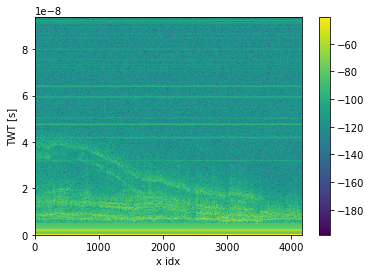

In [83]:
ds = nc.Dataset('/Users/jukesliu/Documents/POSTDOC/snow-radar/data_submission/sample_data_RME/pdriftzigzag_14_v3.nc')
plt.pcolormesh(ds['x'][:], ds['TWT'][:], 
               ds['PDATA'][:], shading='auto')
plt.ylabel('TWT [s]'); plt.xlabel('x idx');
plt.colorbar()
plt.show()

# Renumber files

In [32]:
# take all the v1 files and renumber them!!
submission_datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/data_submission/RME2009_fulldata/'
datafiles = glob.glob(submission_datapath+'*v1.nc')
datafiles.sort()

In [33]:
prefixes = [] # grab all file prefixes
for datafile in datafiles:
    [prefix, number, version] = datafile.split('/')[-1].split('_')
    prefixes.append(prefix)
    
    if len(number) == 1:
        renamed = prefix+'_'+str(number).zfill(2)+'_'+version
        print(renamed) 
        os.rename(datafile, submission_datapath+renamed) # make all nubmers alphanumeric
prefixes = list(set(prefixes))

In [35]:
for prefix in prefixes:
    prefix_files = glob.glob(submission_datapath+prefix+'*v1.nc')
    prefix_files.sort()
    counter = 1
    for datafile in prefix_files:
        [prefix, number, version] = datafile.split('/')[-1].split('_')
        old_name = datafile.split('/')[-1]
        new_name = prefix+'_'+str(counter).zfill(2)+'_v2.nc'
        print(old_name, new_name)
        
        os.rename(datafile, submission_datapath+new_name)
        counter+=1

pdriftzigzag_02_v1.nc pdriftzigzag_01_v2.nc
pdriftzigzag_03_v1.nc pdriftzigzag_02_v2.nc
pdriftzigzag_04_v1.nc pdriftzigzag_03_v2.nc
pdriftzigzag_05_v1.nc pdriftzigzag_04_v2.nc
pdriftzigzag_06_v1.nc pdriftzigzag_05_v2.nc
pdriftzigzag_08_v1.nc pdriftzigzag_06_v2.nc
pdriftzigzag_09_v1.nc pdriftzigzag_07_v2.nc
pdriftzigzag_10_v1.nc pdriftzigzag_08_v2.nc
pdriftzigzag_11_v1.nc pdriftzigzag_09_v2.nc
pdriftzigzag_12_v1.nc pdriftzigzag_10_v2.nc
pdriftzigzag_13_v1.nc pdriftzigzag_11_v2.nc
pdriftzigzag_14_v1.nc pdriftzigzag_12_v2.nc
pdriftzigzag_15_v1.nc pdriftzigzag_13_v2.nc
pt3_02_v1.nc pt3_01_v2.nc
pt3_03_v1.nc pt3_02_v2.nc
pt3_04_v1.nc pt3_03_v2.nc
pt3_05_v1.nc pt3_04_v2.nc
pt3_06_v1.nc pt3_05_v2.nc
pt3_07_v1.nc pt3_06_v2.nc
pt3_09_v1.nc pt3_07_v2.nc
pt3_10_v1.nc pt3_08_v2.nc
pt3_11_v1.nc pt3_09_v2.nc
pt3_12_v1.nc pt3_10_v2.nc
pt3_13_v1.nc pt3_11_v2.nc
pt3_15_v1.nc pt3_12_v2.nc
pt3_16_v1.nc pt3_13_v2.nc
pt3_17_v1.nc pt3_14_v2.nc
pt3_18_v1.nc pt3_15_v2.nc
pt3_19_v1.nc pt3_16_v2.nc
pt3_20_v1.nc